844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8645 - loss: 0.4441 - val_accuracy: 0.9830 - val_loss: 0.0619
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0738

✅ Test Accuracy: 0.9810


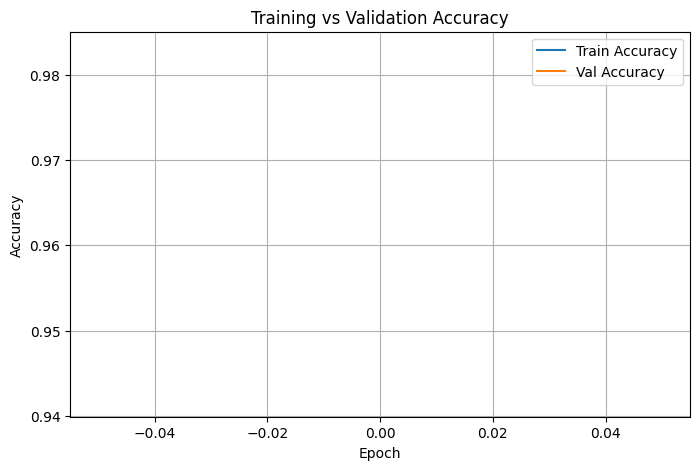

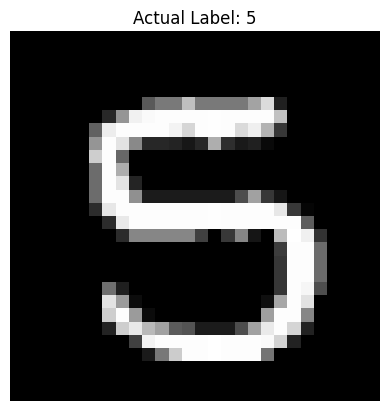

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
🔮 Predicted Label: 5


In [ ]:
# ✅ STEP 1: Install TensorFlow (if not already installed)
# !pip install tensorflow  # Usually pre-installed in Colab

# ✅ STEP 2: Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


# ✅ STEP 3: Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ✅ STEP 4: Preprocess the data
x_train = x_train.reshape((60000, 28, 28, 1)).astype("float32") / 255
x_test = x_test.reshape((10000, 28, 28, 1)).astype("float32") / 255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# ✅ STEP 5: Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])



# ✅ STEP 6: Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ✅ STEP 7: Train the model
history = model.fit(x_train, y_train,
                    epochs=1,
                    batch_size=64,
                    validation_split=0.1)

# ✅ STEP 8: Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# ✅ STEP 9: Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()







import numpy as np

# Pick a random image from test set
index = np.random.randint(0, len(x_test))
sample_image = x_test[index]

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title("Actual Label: " + str(np.argmax(y_test[index])))
plt.axis('off')
plt.show()

# Predict using the model
prediction = model.predict(sample_image.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

print(f"🔮 Predicted Label: {predicted_label}")

